In [1]:
!git clone --recursive https://github.com/naver/dust3r.git
%cd /content/dust3r

!pip install -q -r requirements.txt
!pip install -q open3d shapely trimesh scipy roma

%cd /content


Cloning into 'dust3r'...
remote: Enumerating objects: 611, done.
remote: Total 611 (delta 0), reused 0 (delta 0), pack-reused 611 (from 1)
Receiving objects: 100% (611/611), 756.60 KiB | 18.91 MiB/s, done.
Resolving deltas: 100% (355/355), done.
Submodule 'croco' (https://github.com/naver/croco) registered for path 'croco'
Cloning into '/content/dust3r/croco'...
remote: Enumerating objects: 198, done.        
remote: Counting objects: 100% (87/87), done.        
remote: Compressing objects: 100% (54/54), done.        
remote: Total 198 (delta 54), reused 33 (delta 33), pack-reused 111 (from 1)        
Receiving objects: 100% (198/198), 403.93 KiB | 12.24 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Submodule path 'croco': checked out 'd7de0705845239092414480bd829228723bf20de'
/content/dust3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys
import torch
import numpy as np

sys.path.append('/content/dust3r')

from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference
from dust3r.cloud_opt import global_aligner
from PIL import Image

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/content/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

In [15]:
!gdown --folder 1ivpuKwZ25BosAlM9-YnROKlNPpPk-6Op

Retrieving folder contents
Retrieving folder 1k-GNamI93_NOriowcsIvOfSp9GSRegYZ test1
Processing file 1rmq_AYaEFBhAck5jY4b5ZjMl6BI1T_xY 6a2faabef0290_origin.jpg
Processing file 1RslFQoYRD-DifKArz3-_VqDIkbGfO7us 6a2faabf730ea_origin.jpg
Processing file 19UKbayjY5MTRgvOD560XT53nCyHFVsPT 6a2faabfd9ec4_origin.jpg
Retrieving folder 1Vc3jELHuMdiTWyAZG_C1dYF-rgEyrgEP test2
Processing file 1hTKUCsuDIVaoa5FDo7F4cR24LbA1S5OM 1.jpg
Processing file 1U-aDSyb8yVBewj04ZJGDD-en27ZYa8ku 2.jpg
Processing file 1d3hwWNyczH4NpEEUFXWOqs9B2WWVXraq 3.jpg
Processing file 1lf1OnrnRMnuVlKyAsddAv5gm729FyjqL 4.jpg
Retrieving folder 1EwQ3izk-BKU2739p5rTXmRmUM1whDQEk test3
Processing file 1_8LUa0WoOSjqNg3oOyNgBkWly_msN8tE KakaoTalk_20260623_190119914_02.jpg
Processing file 1tK5SJcqd1zAaKSBBbb4BwYxGoDqDYmjV KakaoTalk_20260623_190119914_03.jpg
Processing file 1_ifH74t4m7hSzcjC_Nj9XJXSBCBtfjZr KakaoTalk_20260623_190119914.jpg
Retrieving folder 1rrfNUL18Mfe9UYCewgvBs0IdHghSp-KT test4
Processing file 19bkajJzjn9LQQyHhdPtd

# 방별 이미지 넣기

In [16]:
import os
os.listdir("/content/02_Data")

['직방사진', 'test3', 'test2', '.gitkeep', 'test4', 'test1']

In [17]:

import glob

target_folder = "/content/02_Data/"
target_image = "직방사진"

target = target_folder+target_image
img_paths = []
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
    img_paths.extend(glob.glob(os.path.join(target, ext)))

img_paths = sorted(img_paths)
for path in img_paths:
    print(f"  - {path}")

# DUSt3R 전용 해상도로 로드
images = load_images(img_paths, size=512) #1024로 돌리면 그냥 망가짐..



  - /content/02_Data/직방사진/방1.png
  - /content/02_Data/직방사진/방2.png
  - /content/02_Data/직방사진/방3.png
  - /content/02_Data/직방사진/방4.png
  - /content/02_Data/직방사진/방5.png
>> Loading a list of 5 images
 - adding /content/02_Data/직방사진/방1.png with resolution 1180x884 --> 512x384
 - adding /content/02_Data/직방사진/방2.png with resolution 1188x890 --> 512x384
 - adding /content/02_Data/직방사진/방3.png with resolution 1178x884 --> 512x384
 - adding /content/02_Data/직방사진/방4.png with resolution 1182x886 --> 512x384
 - adding /content/02_Data/직방사진/방5.png with resolution 1182x890 --> 512x384
 (Found 5 images)


pointmaps / pts3d - 3D 공간 좌표
pixel_4d_matrix - 4차원 공간 데이터 매트릭스

In [18]:

# 3. 이미지 쌍 빌드 및 기하학 추론
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
with torch.no_grad():
    output = inference(pairs, model, device, batch_size=2)

# 4. 글로벌 정렬 최적화
scene = global_aligner(output, device=device)
scene.compute_global_alignment(niter=300, init="mst")

pointmaps = scene.get_pts3d()
confidences = scene.get_conf()

for i in range(len(img_paths)):
    pts3d = pointmaps[i].detach().cpu().numpy()     # (512, 512, 3)
    conf = confidences[i].detach().cpu().numpy()       # (512, 512)
    conf_expanded = np.expand_dims(conf, axis=-1)    # (512, 512, 1)

    # 4차원 결합
    pixel_4d_matrix = np.concatenate([pts3d, conf_expanded], axis=-1)   # (512, 512, 4)

>> Inference with model on 20 image pairs


  0%|          | 0/10 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 10/10 [00:13<00:00,  1.31s/it]


 init edge (1*,3*) score=np.float64(204.272216796875)
 init edge (3,4*) score=np.float64(198.1202392578125)
 init edge (2*,1) score=np.float64(159.60809326171875)
 init edge (0*,1) score=np.float64(129.06771850585938)
 init loss = 0.016705427318811417
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 300/300 [00:23<00:00, 13.01it/s, lr=1.27413e-06 loss=0.00968135]


In [13]:
pixel_4d_matrix

array([[[-0.01823453, -0.12706107,  0.18649408,  2.1051598 ],
        [-0.01884259, -0.13342617,  0.19227181,  2.6191638 ],
        [-0.01846755, -0.13373904,  0.19229138,  2.723172  ],
        ...,
        [ 0.14058688, -0.12608048,  0.081958  ,  2.8448763 ],
        [ 0.14103754, -0.12609938,  0.0816797 ,  2.8289924 ],
        [ 0.13822292, -0.12290926,  0.08082086,  1.9584484 ]],

       [[-0.01938729, -0.13373114,  0.1933708 ,  2.552083  ],
        [-0.01878791, -0.13264664,  0.192059  ,  2.783379  ],
        [-0.01837116, -0.1326871 ,  0.19182128,  2.6921954 ],
        ...,
        [ 0.14154916, -0.12651242,  0.08217247,  2.8336067 ],
        [ 0.14170352, -0.12623727,  0.08183816,  2.908313  ],
        [ 0.14028578, -0.12442476,  0.08122539,  2.7105594 ]],

       [[-0.01894393, -0.13057204,  0.19087826,  2.5386362 ],
        [-0.01870531, -0.13169432,  0.19167891,  2.667159  ],
        [-0.01819761, -0.13114749,  0.19088149,  2.61653   ],
        ...,
        [ 0.14294545, -0.12

In [11]:
import os
import json
from IPython.display import HTML, display
from dust3r.demo import get_3D_model_from_scene

print("📦 1. 최적화된 scene 객체로부터 GLB 파일 생성 중...")
# 안전하게 파일 생성 (기존에 만들어둔 glb가 있다면 outdir 경로만 맞춰주세요)
glb_path = get_3D_model_from_scene(
    outdir="/content",
    silent=True,
    scene=scene,
    min_conf_thr=1.0, # 바닥과 가구가 풍성하게 나오도록 1.0 세팅
    as_pointcloud=False # 툴팁을 붙이려면 메쉬(Mesh) 형태가 시각적으로 좋습니다
)

# 2. [핵심] 가구가 있는 실제 3D 좌표 지정하기
# 원래는 2D 객체인식(YOLO)이나 픽셀 매트릭스에서 가져오지만,
# 데모용으로 방 한가운데(0,0,0) 근처의 가구 위치를 가상으로 지정합니다.
# 단위는 미터(m)입니다. 내 방 구조에 맞춰 수치를 조금씩 변경해보세요!
bed_coords = "0.2m 0.5m -1.2m"      # X, Y, Z 축 위치
refrigerator_coords = "-0.6m 0.5m -1.8m"

print("🎨 2. 마우스 오버 인터랙션이 포함된 3D 웹 HTML 생성 중...")

# 구글 <model-viewer> 엔진을 활용한 인터랙티브 HTML 템플릿 코드 작성
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <script type="module" src="https://ajax.googleapis.com/ajax/libs/model-viewer/3.5.0/model-viewer.min.js"></script>
    <style>
        body {{ margin: 0; padding: 0; background-color: #f5f5f7; font-family: sans-serif; }}
        model-viewer {{ width: 100%; height: 550px; background-color: #ffffff; border-radius: 12px; }}

        /* 핫스팟(점) 스타일 */
        .hotspot {{
            width: 14px; height: 14px; border-radius: 50%;
            background: #0071e3; border: 2px solid #ffffff;
            cursor: pointer; box-shadow: 0 2px 4px rgba(0,0,0,0.3);
            transition: transform 0.2s;
        }}
        .hotspot:hover {{ transform: scale(1.3); }}

        /* 마우스 올렸을 때 나타날 툴팁 문자 상자 스타일 */
        .tooltip {{
            visibility: hidden; opacity: 0;
            background: rgba(33, 33, 33, 0.9); color: #ffffff;
            padding: 6px 12px; border-radius: 6px; font-size: 13px; font-weight: bold;
            position: absolute; left: 20px; top: -10px; white-space: nowrap;
            box-shadow: 0 4px 10px rgba(0,0,0,0.2);
            transition: opacity 0.2s ease, visibility 0.2s;
        }}

        /* 마우스 오버(Hover) 시 텍스트 활성화 */
        .hotspot:hover .tooltip {{
            visibility: visible; opacity: 1;
        }}
    </style>
</head>
<body>

    <div style="padding: 15px;">
        <h3 style="margin: 0 0 10px 0; color: #333;">🏡 원룸 3D 인테리어 인터랙티브 뷰어</h3>
        <p style="margin: 0 0 15px 0; font-size: 13px; color: #666;">파란색 포인트에 마우스를 올리면(Hover) 가구 정보가 나타납니다. 마우스 드래그로 회전해 보세요.</p>

        <model-viewer src="files/content/scene.glb" camera-controls auto-rotate shadow-intensity="1">

            <button class="hotspot" slot="hotspot-bed" data-position="{bed_coords}" data-normal="0m 1m 0m">
                <div class="tooltip">🛏️ 옵션 침대 (Standard Size)</div>
            </button>

            <button class="hotspot" slot="hotspot-ref" data-position="{refrigerator_coords}" data-normal="0m 1m 0m">
                <div class="tooltip">🧊 빌트인 냉장고 (250L)</div>
            </button>

        </model-viewer>
    </div>

</body>
</html>
"""

# 3. 코랩 세션 내부에 가상 웹브라우저 창을 열어 결과 시각화하기
display(HTML(html_content))
print("✨ 렌더링 완료! 위 화면에서 직접 마우스를 올려 확인해 보세요.")

📦 1. 최적화된 scene 객체로부터 GLB 파일 생성 중...
🎨 2. 마우스 오버 인터랙션이 포함된 3D 웹 HTML 생성 중...


✨ 렌더링 완료! 위 화면에서 직접 마우스를 올려 확인해 보세요.


In [12]:
import os
import base64
from google.colab import files

# 1. 기존에 생성된 3D GLB 파일 경로 지정
# (앞 단계에서 저장한 파일명에 맞게 수정하세요. 기본은 scene.glb 또는 복구용 파일)
glb_path = "/content/scene.glb"

if not os.path.exists(glb_path):
    # 만약 변수명 기반으로 저장되어 찾기 어려울 경우를 대비해 전수조사
    import glob
    found_glbs = glob.glob("/content/*.glb")
    if found_glbs:
        glb_path = found_glbs[0]
        print(f"📂 자동으로 탐색된 3D 파일 경로: {glb_path}")
    else:
        print("❌ 에러: /content/ 폴더 안에 복원된 .glb 파일이 존재하지 않습니다.")
        print("👉 앞 단계의 GLB 생성 셀을 먼저 실행해 주세요!")
        glb_path = None

if glb_path:
    print("🧬 3D 바이너리 데이터를 Base64 텍스트 코드로 복제 중...")
    # 2. GLB 파일을 읽어서 브라우저가 바로 인식할 수 있는 Base64 스트링으로 변환 (보안 우회 핵심)
    with open(glb_path, "rb") as f:
        glb_binary = f.read()
        glb_base64 = base64.b64encode(glb_binary).decode('utf-8')

    # 데이터 URL 포맷 생성
    glb_data_url = f"data:model/gltf-binary;base64,{glb_base64}"

    # 3. 마우스 오버 인터랙션이 포함된 단독 실행형 HTML 코드 작성
    # 가상 가구 좌표 세팅 (내 방의 구조에 맞춰 미터 단위 튜닝 가능)
    bed_coords = "0.2m 0.5m -1.2m"
    refrigerator_coords = "-0.6m 0.5m -1.8m"

    html_template = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>원룸 3D 인터랙티브 도면 뷰어</title>
    <script type="module" src="https://ajax.googleapis.com/ajax/libs/model-viewer/3.5.0/model-viewer.min.js"></script>
    <style>
        body {{
            margin: 0; padding: 0;
            background-color: #f5f5f7;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
            display: flex; justify-content: center; align-items: center;
            height: 100vh;
        }}
        .container {{
            width: 90%; max-width: 1000px; height: 80vh;
            background: #ffffff; padding: 24px; border-radius: 16px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.08);
            box-sizing: border-box; display: flex; flex-direction: column;
        }}
        model-viewer {{
            width: 100%; flex: 1;
            background-color: #fafafa; border-radius: 12px;
            border: 1px solid #e5e5e7;
        }}
        /* 핫스팟(포인트 점) 디자인 */
        .hotspot {{
            width: 16px; height: 16px; border-radius: 50%;
            background: #0071e3; border: 3px solid #ffffff;
            cursor: pointer; box-shadow: 0 4px 8px rgba(0,0,0,0.25);
            transition: transform 0.2s ease;
            padding: 0; outline: none;
        }}
        .hotspot:hover {{ transform: scale(1.3); background: #ff453a; }}

        /* 마우스 올렸을 때 튀어나오는 문자 상자(Tooltip) */
        .tooltip {{
            visibility: hidden; opacity: 0;
            background: rgba(28, 28, 30, 0.95); color: #ffffff;
            padding: 8px 14px; border-radius: 8px;
            font-size: 13px; font-weight: 600; letter-spacing: -0.3px;
            position: absolute; left: 24px; top: -5px; white-space: nowrap;
            box-shadow: 0 4px 12px rgba(0,0,0,0.15);
            transition: opacity 0.2s ease, visibility 0.2s;
            pointer-events: none;
        }}
        /* Hover 시 토글 활성화 */
        .hotspot:hover .tooltip {{
            visibility: visible; opacity: 1;
        }}
    </style>
</head>
<body>

    <div class="container">
        <div style="margin-bottom: 16px;">
            <h2 style="margin: 0 0 4px 0; color: #1d1d1f;">🏡 원룸 3D 가상 투어 시스템</h2>
            <p style="margin: 0; font-size: 14px; color: #86868b;">파란색 마커에 마우스를 올리면 가구 오브젝트 정보가 팝업됩니다. 화면을 드래그하여 회전할 수 있습니다.</p>
        </div>

        <model-viewer src="{glb_data_url}" camera-controls auto-rotate shadow-intensity="1.5" exposure="1.0">

            <button class="hotspot" slot="hotspot-bed" data-position="{bed_coords}" data-normal="0m 1m 0m">
                <div class="tooltip">🛏️ 옵션 가구: 수납형 침대 (SS Size)</div>
            </button>

            <button class="hotspot" slot="hotspot-ref" data-position="{refrigerator_coords}" data-normal="0m 1m 0m">
                <div class="tooltip">🧊 기본 옵션: 빌트인 냉장고 (210L)</div>
            </button>

        </model-viewer>
    </div>

</body>
</html>
"""

    # 4. 파일 저장 및 즉시 다운로드 실행
    output_html_path = "/content/interactive_viewer.html"
    with open(output_html_path, "w", encoding="utf-8") as html_file:
        html_file.write(html_template)

    print("💾 단독 실행형 HTML 페이지 패키징 완료!")
    print("📥 로컬 PC로 다운로드를 시작합니다... (팝업창을 허용해 주세요)")
    files.download(output_html_path)

🧬 3D 바이너리 데이터를 Base64 텍스트 코드로 복제 중...
💾 단독 실행형 HTML 페이지 패키징 완료!
📥 로컬 PC로 다운로드를 시작합니다... (팝업창을 허용해 주세요)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# glb저장

In [20]:
import shutil
import os, glob, open3d as o3d
from google.colab import files
from dust3r.demo import get_3D_model_from_scene

output_filepath = get_3D_model_from_scene(
    outdir="/content",
    silent=False,
    scene=scene,
    min_conf_thr=2.0,     # 신뢰도 임계값
    as_pointcloud=False,    # T(점)/F(매시) T가 조금 더 깔끔?
    mask_sky = False,  # 구름(실내사진으로 false고정)
    clean_depth=False,            # Clean-up depthmaps
    transparent_cams=True        # 카메라 위치
)

if os.path.exists("/content/scene.glb"):
    shutil.move("/content/scene.glb", f"/content/{target_image}.glb")

    # 다운로드
    files.download(f"/content/{target_image}.glb")
else:
    print("/content/scene.glb 파일을 찾지 못했습니다")

(exporting 3D scene to /content/scene.glb )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###2D로

🔍 3D 점구름 공간 형태 정밀 진단 시작...
✅ 총 567531개의 공간 정점 추출 완료. 3방향 투영 분석을 시작합니다.


/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 45720 (\N{HANGUL SYLLABLE NEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8419/2311987501.py:53: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_lay

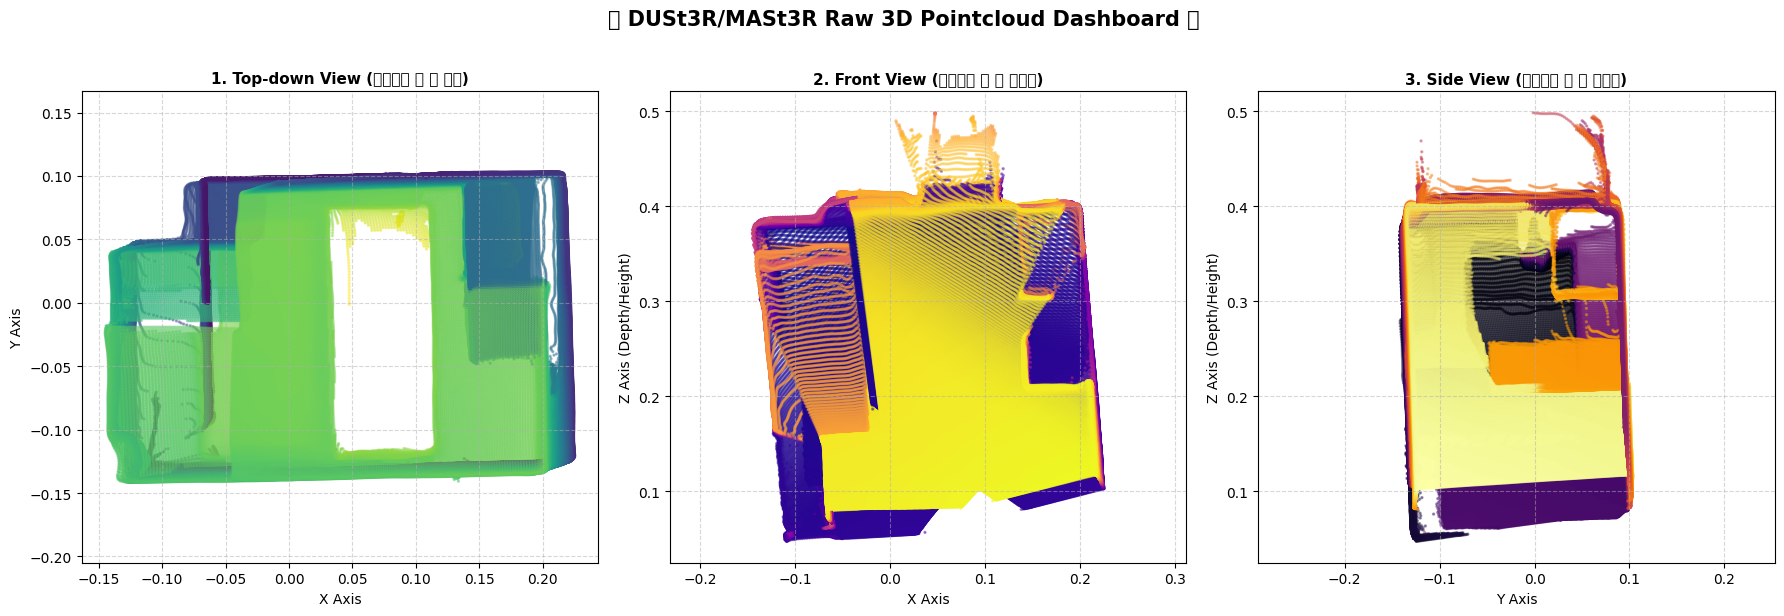

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 메모리의 점구름 데이터 정제 및 병합
diagnostic_pts = []
for i in range(len(pointmaps)):
    pts = pointmaps[i].detach().cpu().numpy().reshape(-1, 3)
    conf = confidences[i].detach().cpu().numpy().reshape(-1)

    # 신뢰도가 너무 매끄럽지 못한 점 필터링 (우선 1.0 기준)
    mask = conf > 1.0
    diagnostic_pts.append(pts[mask])

pts_final = np.concatenate(diagnostic_pts, axis=0)

if len(pts_final) == 0:
    print("❌ 경고: 신뢰도 기준(1.0)을 넘는 유효한 3D 점이 단 한 개도 없습니다!")
    print("👉 원인: 현재 데이터가 특징 없는 '더미 이미지'이거나 모델 추론이 실패한 상태입니다.")
else:
    print(f"✅ 총 {len(pts_final)}개의 공간 정점 추출 완료. 3방향 투영 분석을 시작합니다.")

    # 2. Matplotlib 3단 분할 진단 대시보드 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # [뷰 1] 위에서 아래로 내려다본 모양 (X-Y 축)
    # 뒤쪽 점일수록 밝게 보이도록 Z축 값을 컬러맵으로 지정
    sc0 = axes[0].scatter(pts_final[:, 0], pts_final[:, 1], c=pts_final[:, 2], cmap='viridis', s=2, alpha=0.4)
    axes[0].set_title("1. Top-down View (하늘에서 본 방 구조)", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("X Axis")
    axes[0].set_ylabel("Y Axis")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].axis('equal')

    # [뷰 2] 정면에서 바라본 모양 (X-Z 축)
    sc1 = axes[1].scatter(pts_final[:, 0], pts_final[:, 2], c=pts_final[:, 1], cmap='plasma', s=2, alpha=0.4)
    axes[1].set_title("2. Front View (정면에서 본 방 높낮이)", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("X Axis")
    axes[1].set_ylabel("Z Axis (Depth/Height)")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].axis('equal')

    # [뷰 3] 측면에서 바라본 모양 (Y-Z 축)
    sc2 = axes[2].scatter(pts_final[:, 1], pts_final[:, 2], c=pts_final[:, 0], cmap='inferno', s=2, alpha=0.4)
    axes[2].set_title("3. Side View (옆면에서 본 방 깊이감)", fontsize=11, fontweight='bold')
    axes[2].set_xlabel("Y Axis")
    axes[2].set_ylabel("Z Axis (Depth/Height)")
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].axis('equal')

    plt.suptitle("🚨 DUSt3R/MASt3R Raw 3D Pointcloud Dashboard 🚨", fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()